## Analisis de Datos Exploratorio Multivariable (EDA)

### By:
Miguel Angel Toro Ramos

### Date:
2026-08-20

### Description:

Realizar un buen análisis de datos exploratorio (EDA) para caracterizar los datos disponibles para el proyecto.

## 📚 Import  libraries

In [44]:
# base libraries for data science
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [45]:
# configuration to show only 2 decimal places
pd.set_option("display.float_format", "{:.2f}".format)

In [46]:
# print library version for reproducibility

print("Python version: ", sys.version)
print("Pandas version: ", pd.__version__)

Python version:  3.12.3 (main, Jun 19 2026, 12:46:00) [GCC 13.3.0]
Pandas version:  3.0.5


## 💾 Load data

In [47]:
DATA_DIR = Path.cwd().resolve().parents[0] / "Admisiones-predict-project" / "data"

admisiones_df = pd.read_parquet(
    DATA_DIR / "02_intermediate/admisiones_type_fixed.parquet", engine="pyarrow"
)

In [48]:
admisiones_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 623 entries, 0 to 622
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          612 non-null    Int64  
 1   TOEFL Score        604 non-null    Int64  
 2   University Rating  617 non-null    Int64  
 3   SOP                607 non-null    float64
 4   LOR                615 non-null    float64
 5   CGPA               621 non-null    float64
 6   Research           594 non-null    boolean
 7   Chance of Admit    623 non-null    float64
dtypes: Int64(3), boolean(1), float64(4)
memory usage: 37.2 KB


In [49]:
admisiones_df.shape

(623, 8)

In [50]:
# sample of the dataframe
admisiones_df.sample(10)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
261,312,104,3,3.50,4.00,8.09,False,0.71
238,310,104,3,2.00,3.50,8.37,False,0.70
223,308,109,2,3.00,4.00,8.45,False,0.71
189,324,112,5,5.00,5.00,9.08,True,0.88
453,300,100,3,2.00,3.00,8.66,True,0.64
23,334,119,5,5.00,4.50,9.70,True,0.95
435,338,117,4,3.50,4.50,9.46,True,0.91
604,334,114,4,4.00,4.00,9.43,True,0.93
251,316,99,2,2.50,3.00,9.00,False,0.70
266,312,105,2,2.00,2.50,8.45,False,0.72


In [51]:
admisiones_df.isnull().sum()

GRE Score            11
TOEFL Score          19
University Rating     6
SOP                  16
LOR                   8
CGPA                  2
Research             29
Chance of Admit       0
dtype: int64

## General statistics of the data set
### Numerical variables

In [52]:
admisiones_df.describe()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Chance of Admit
count,612.00,604.00,617.00,607.00,615.00,621.00,623.00
mean,317.09,107.87,3.18,3.46,3.52,8.64,0.73
std,11.75,6.12,1.15,1.01,0.87,0.59,0.14
min,290.00,92.00,1.00,1.00,1.00,6.80,0.34
25%,309.00,104.00,2.00,3.00,3.00,8.22,0.64
50%,317.00,108.00,3.00,3.50,3.50,8.65,0.73
75%,326.00,112.00,4.00,4.00,4.00,9.10,0.84
max,340.00,120.00,5.00,5.00,5.00,9.92,0.97


### Categorical variables

In [53]:
admisiones_df.describe(include="bool")

,Research
count,594
unique,2
top,True
freq,327


## 📈 Análisis multivariable

Este análisis estudia los predictores de manera conjunta para preparar diagnósticos y visualizaciones exploratorias. No ajusta ni evalúa modelos predictivos.

### Conjunto exploratorio de casos completos

Se construye un subconjunto con casos completos para las visualizaciones y diagnósticos que requieren todas las variables seleccionadas. La comparación explicita el número de filas antes y después. Esta exclusión es **solo exploratoria**: no define la estrategia final para los datos faltantes ni debe aplicarse antes de separar entrenamiento y prueba.

In [ ]:
TARGET_COLUMN = "Chance of Admit "
RESEARCH_COLUMN = "Research"
NUMERIC_PREDICTOR_COLUMNS = [
    "GRE Score",
    "TOEFL Score",
    "University Rating",
    "SOP",
    "LOR ",
    "CGPA",
]
SELECTED_FEATURE_COLUMNS = [*NUMERIC_PREDICTOR_COLUMNS, RESEARCH_COLUMN]
EXPLORATORY_ANALYSIS_COLUMNS = [*SELECTED_FEATURE_COLUMNS, TARGET_COLUMN]

complete_case_exploratory_df = admisiones_df[EXPLORATORY_ANALYSIS_COLUMNS].dropna().copy()
complete_case_summary = pd.DataFrame(
    {
        "filas": [
            len(admisiones_df),
            len(complete_case_exploratory_df),
        ],
        "porcentaje_del_total": [
            100.0,
            100.0 * len(complete_case_exploratory_df) / len(admisiones_df),
        ],
    },
    index=["Antes: filas originales", "Después: casos completos exploratorios"],
)
complete_case_summary

,filas,porcentaje_del_total
Antes: filas originales,623,100.00
Después: casos completos exploratorios,552,88.60


### Correlación entre predictores y objetivo

El mapa usa correlación de Pearson y calcula cada coeficiente con los pares disponibles, sin imputar valores. Incluye todos los predictores numéricos y la variable objetivo; por tanto, los tamaños muestrales pueden diferir entre pares. La correlación resume asociación lineal y no identifica causalidad, interacciones ni efectos condicionados por otras variables.

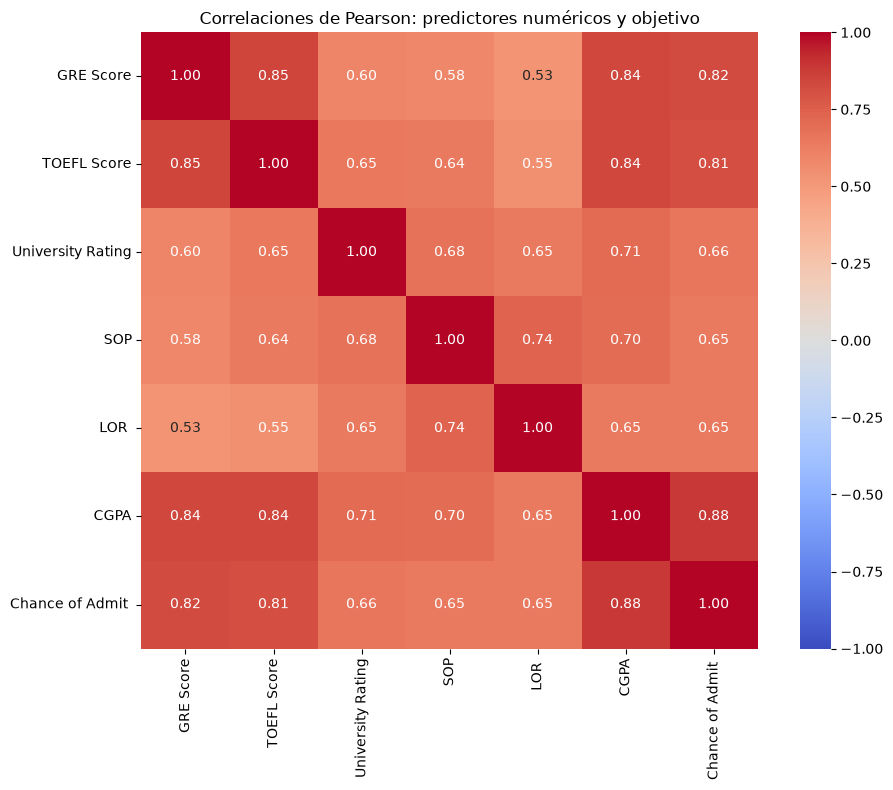

In [55]:
NUMERIC_ANALYSIS_COLUMNS = [*NUMERIC_PREDICTOR_COLUMNS, TARGET_COLUMN]
HEATMAP_MIN_VALUE = -1.0
HEATMAP_MAX_VALUE = 1.0
HEATMAP_CENTER_VALUE = 0.0
HEATMAP_FIGURE_SIZE = (10, 8)

numeric_correlations = admisiones_df[NUMERIC_ANALYSIS_COLUMNS].corr(method="pearson")
plt.figure(figsize=HEATMAP_FIGURE_SIZE)
sns.heatmap(
    numeric_correlations,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=HEATMAP_MIN_VALUE,
    vmax=HEATMAP_MAX_VALUE,
    center=HEATMAP_CENTER_VALUE,
    square=True,
)
plt.title("Correlaciones de Pearson: predictores numéricos y objetivo")
plt.tight_layout()
plt.show()

### CGPA y GRE Score frente al objetivo, por Research

Las facetas separan los grupos `Research=True`, `Research=False` y `Research` faltante. Para cada panel se excluyen únicamente los valores faltantes en el predictor mostrado o en el objetivo; los faltantes de `Research` se conservan y se etiquetan como `Sin dato` en vez de asignarlos a un grupo observado.

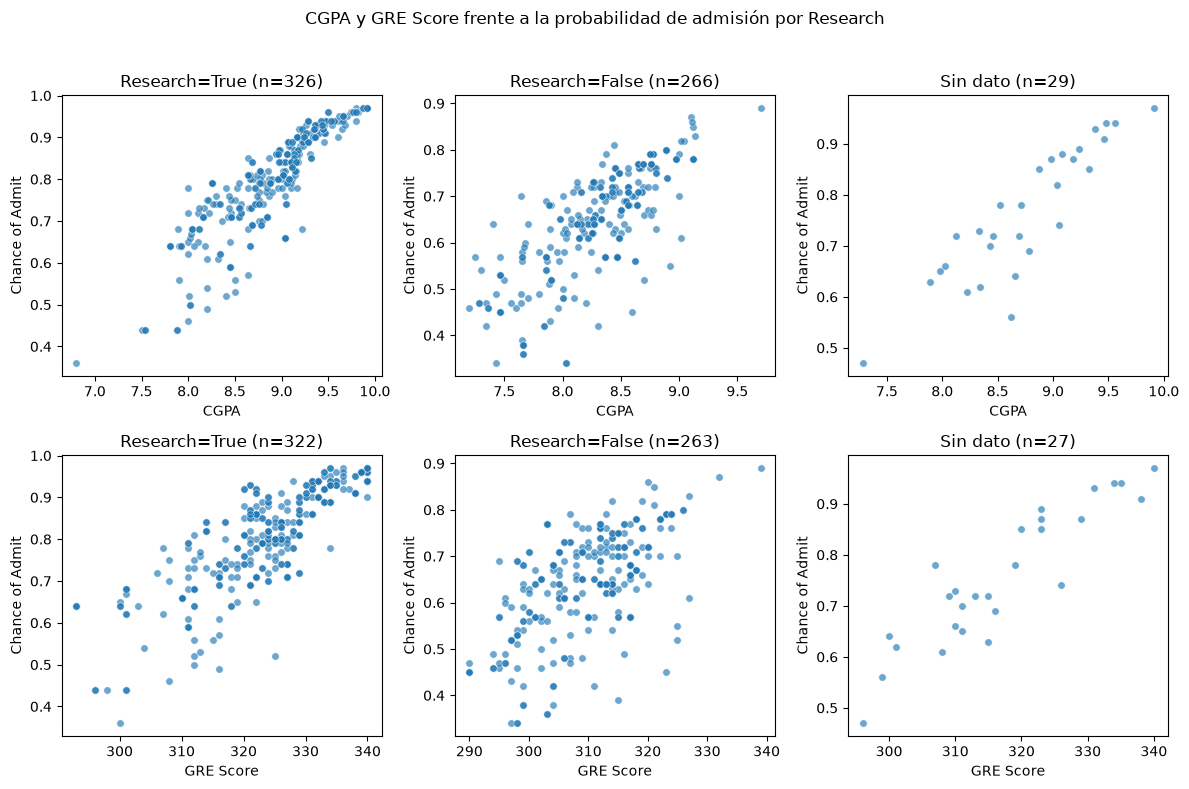

In [56]:
PLOT_PREDICTOR_COLUMNS = ["CGPA", "GRE Score"]
RESEARCH_GROUP_COLUMN = "Grupo de Research"
RESEARCH_GROUP_LABELS = {
    True: "Research=True",
    False: "Research=False",
}
MISSING_RESEARCH_LABEL = "Sin dato"
RESEARCH_GROUP_ORDER = [
    RESEARCH_GROUP_LABELS[True],
    RESEARCH_GROUP_LABELS[False],
    MISSING_RESEARCH_LABEL,
]
PLOT_COLUMN_COUNT = len(RESEARCH_GROUP_ORDER)
PLOT_WIDTH_PER_COLUMN = 4
PLOT_HEIGHT_PER_ROW = 4
POINT_ALPHA = 0.65
POINT_SIZE = 28

research_visualization_df = admisiones_df[
    [*PLOT_PREDICTOR_COLUMNS, TARGET_COLUMN, RESEARCH_COLUMN]
].copy()
research_visualization_df[RESEARCH_GROUP_COLUMN] = (
    research_visualization_df[RESEARCH_COLUMN]
    .map(RESEARCH_GROUP_LABELS)
    .fillna(MISSING_RESEARCH_LABEL)
)

figure, axes = plt.subplots(
    nrows=len(PLOT_PREDICTOR_COLUMNS),
    ncols=PLOT_COLUMN_COUNT,
    figsize=(
        PLOT_WIDTH_PER_COLUMN * PLOT_COLUMN_COUNT,
        PLOT_HEIGHT_PER_ROW * len(PLOT_PREDICTOR_COLUMNS),
    ),
    squeeze=False,
)

for predictor_index, predictor_column in enumerate(PLOT_PREDICTOR_COLUMNS):
    for group_index, research_group in enumerate(RESEARCH_GROUP_ORDER):
        axis = axes[predictor_index, group_index]
        plot_data = research_visualization_df.loc[
            research_visualization_df[RESEARCH_GROUP_COLUMN].eq(research_group),
            [predictor_column, TARGET_COLUMN],
        ].dropna()
        sns.scatterplot(
            data=plot_data,
            x=predictor_column,
            y=TARGET_COLUMN,
            alpha=POINT_ALPHA,
            s=POINT_SIZE,
            ax=axis,
        )
        axis.set_title(f"{research_group} (n={len(plot_data)})")
        axis.set_xlabel(predictor_column)
        axis.set_ylabel(TARGET_COLUMN.strip())

figure.suptitle("CGPA y GRE Score frente a la probabilidad de admisión por Research")
figure.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

### Asociación condicional de CGPA y GRE Score por Research

La tabla resume, para cada predictor y grupo de `Research`, el número de pares completos, la asociación de Pearson con el objetivo y la media del objetivo. `Sin dato` representa explícitamente los valores faltantes de `Research`; no se interpreta como `Research=False`. Las diferencias son descriptivas y el grupo pequeño o con datos faltantes puede producir estimaciones inestables.

In [71]:
CONDITIONAL_ASSOCIATION_COLUMNS = [
    "Grupo de Research",
    "predictor",
    "observaciones",
    "asociacion_pearson",
    "media_objetivo",
]
MINIMUM_PEARSON_OBSERVATIONS = 2

conditional_association_records = []
for research_group in RESEARCH_GROUP_ORDER:
    group_data = research_visualization_df.loc[
        research_visualization_df[RESEARCH_GROUP_COLUMN].eq(research_group)
    ]
    for predictor_column in PLOT_PREDICTOR_COLUMNS:
        pairwise_complete_data = group_data[[predictor_column, TARGET_COLUMN]].dropna()
        observation_count = len(pairwise_complete_data)
        pearson_association = (
            pairwise_complete_data[predictor_column].corr(pairwise_complete_data[TARGET_COLUMN])
            if observation_count >= MINIMUM_PEARSON_OBSERVATIONS
            else np.nan
        )
        conditional_association_records.append(
            {
                "Grupo de Research": research_group,
                "predictor": predictor_column,
                "observaciones": observation_count,
                "asociacion_pearson": pearson_association,
                "media_objetivo": pairwise_complete_data[TARGET_COLUMN].mean(),
            }
        )

conditional_association_by_research = pd.DataFrame(
    conditional_association_records, columns=CONDITIONAL_ASSOCIATION_COLUMNS
)
conditional_association_by_research[RESEARCH_GROUP_COLUMN] = pd.Categorical(
    conditional_association_by_research[RESEARCH_GROUP_COLUMN],
    categories=RESEARCH_GROUP_ORDER,
    ordered=True,
)
display(
    conditional_association_by_research.sort_values(
        [RESEARCH_GROUP_COLUMN, "predictor"]
    ).style.format({"asociacion_pearson": "{:.3f}", "media_objetivo": "{:.3f}"})
)

,Grupo de Research,predictor,observaciones,asociacion_pearson,media_objetivo
0,Research=True,CGPA,326,0.886,0.804
1,Research=True,GRE Score,322,0.808,0.805
2,Research=False,CGPA,266,0.750,0.642
3,Research=False,GRE Score,263,0.605,0.642
4,Sin dato,CGPA,29,0.891,0.763
5,Sin dato,GRE Score,27,0.909,0.757


### Cribado de multicolinealidad

La tabla presenta los pares de predictores con correlación absoluta igual o superior al umbral declarado. Es un cribado descriptivo, no una regla de eliminación automática: puede omitir dependencias conjuntas entre varias variables y no detecta relaciones no lineales. En modelos sensibles a multicolinealidad, el diagnóstico debe repetirse dentro del flujo de entrenamiento y contrastarse con la estabilidad de los coeficientes.

In [57]:
from itertools import combinations

COLLINEARITY_SCREENING_THRESHOLD = 0.70
CORRELATION_METHOD = "pearson"

predictor_correlations = complete_case_exploratory_df[NUMERIC_PREDICTOR_COLUMNS].corr(
    method=CORRELATION_METHOD
)
collinearity_pairs = [
    {
        "predictor_1": first_predictor,
        "predictor_2": second_predictor,
        "correlacion_pearson": predictor_correlations.loc[first_predictor, second_predictor],
    }
    for first_predictor, second_predictor in combinations(NUMERIC_PREDICTOR_COLUMNS, 2)
]
collinearity_screening = (
    pd.DataFrame(collinearity_pairs)
    .assign(correlacion_absoluta=lambda table: table["correlacion_pearson"].abs())
    .query("correlacion_absoluta >= @COLLINEARITY_SCREENING_THRESHOLD")
    .sort_values("correlacion_absoluta", ascending=False)
    .reset_index(drop=True)
)
collinearity_screening.style.format(
    {"correlacion_pearson": "{:.3f}", "correlacion_absoluta": "{:.3f}"}
)

,predictor_1,predictor_2,correlacion_pearson,correlacion_absoluta
0,GRE Score,CGPA,0.843,0.843
1,GRE Score,TOEFL Score,0.838,0.838
2,TOEFL Score,CGPA,0.836,0.836
3,SOP,LOR,0.735,0.735
4,SOP,CGPA,0.709,0.709
5,University Rating,CGPA,0.706,0.706


### Diagnóstico VIF de multicolinealidad

El factor de inflación de la varianza (VIF) se calcula manualmente con los predictores numéricos de casos completos. Es un diagnóstico para modelos lineales o basados en coeficientes, no una regla automática para descartar variables. Si se usa durante el modelado, debe recalcularse dentro de cada partición de entrenamiento.

In [72]:
VIF_ZERO_VARIANCE_TOLERANCE = 1e-12
VIF_NEAR_PERFECT_R_SQUARED_TOLERANCE = 1e-12
VIF_MINIMUM_R_SQUARED = 0.0
VIF_MAXIMUM_R_SQUARED = 1.0
VIF_INTERCEPT_VALUE = 1.0
VIF_INFINITE_VALUE = np.inf


def calculate_vif(numeric_predictor_data):
    vif_values = []
    predictor_matrix = numeric_predictor_data.to_numpy(dtype=float)

    for predictor_index, predictor_column in enumerate(numeric_predictor_data.columns):
        predictor_values = predictor_matrix[:, predictor_index]
        if np.var(predictor_values) <= VIF_ZERO_VARIANCE_TOLERANCE:
            vif_values.append({"predictor": predictor_column, "VIF": VIF_INFINITE_VALUE})
            continue

        remaining_predictors = np.delete(predictor_matrix, predictor_index, axis=1)
        design_matrix = np.column_stack(
            (np.full(len(predictor_values), VIF_INTERCEPT_VALUE), remaining_predictors)
        )
        coefficients, _, _, _ = np.linalg.lstsq(design_matrix, predictor_values, rcond=None)
        residuals = predictor_values - design_matrix @ coefficients
        total_sum_squares = np.sum((predictor_values - predictor_values.mean()) ** 2)
        residual_sum_squares = np.sum(residuals**2)

        if total_sum_squares <= VIF_ZERO_VARIANCE_TOLERANCE:
            vif_value = VIF_INFINITE_VALUE
        else:
            r_squared = VIF_MAXIMUM_R_SQUARED - (residual_sum_squares / total_sum_squares)
            bounded_r_squared = min(max(r_squared, VIF_MINIMUM_R_SQUARED), VIF_MAXIMUM_R_SQUARED)
            vif_value = (
                VIF_INFINITE_VALUE
                if bounded_r_squared
                >= (VIF_MAXIMUM_R_SQUARED - VIF_NEAR_PERFECT_R_SQUARED_TOLERANCE)
                else VIF_INTERCEPT_VALUE / (VIF_MAXIMUM_R_SQUARED - bounded_r_squared)
            )

        vif_values.append({"predictor": predictor_column, "VIF": vif_value})

    return pd.DataFrame(vif_values).sort_values("VIF", ascending=False).reset_index(drop=True)


complete_case_numeric_predictors = complete_case_exploratory_df[NUMERIC_PREDICTOR_COLUMNS]
vif_diagnostic = calculate_vif(complete_case_numeric_predictors)
display(vif_diagnostic.style.format({"VIF": "{:.3f}"}))

,predictor,VIF
0,CGPA,5.580
1,GRE Score,4.372
2,TOEFL Score,4.334
3,SOP,2.918
4,LOR,2.483
5,University Rating,2.429


### Perfiles de solicitantes por cuantiles conjuntos de CGPA y GRE Score

Los terciles de `CGPA` y `GRE Score` se derivan sobre estos datos solo para exploración y visualización. La tabla conjunta informa recuentos y resumen del objetivo por perfil. Si los límites cuantiles o estos perfiles se utilizaran más adelante en una regla o modelo, deben recalcularse exclusivamente con los datos de entrenamiento.

In [73]:
PROFILE_CGPA_COLUMN = "Perfil CGPA"
PROFILE_GRE_COLUMN = "Perfil GRE Score"
PROFILE_QUANTILE_COUNT = 3
PROFILE_QUANTILE_LABELS = ["Bajo", "Medio", "Alto"]
PROFILE_SUMMARY_COLUMNS = [
    PROFILE_CGPA_COLUMN,
    PROFILE_GRE_COLUMN,
    "filas",
    "media_objetivo",
    "mediana_objetivo",
]

joint_profile_data = admisiones_df[["CGPA", "GRE Score", TARGET_COLUMN]].dropna().copy()
joint_profile_data[PROFILE_CGPA_COLUMN] = pd.qcut(
    joint_profile_data["CGPA"],
    q=PROFILE_QUANTILE_COUNT,
    labels=PROFILE_QUANTILE_LABELS,
)
joint_profile_data[PROFILE_GRE_COLUMN] = pd.qcut(
    joint_profile_data["GRE Score"],
    q=PROFILE_QUANTILE_COUNT,
    labels=PROFILE_QUANTILE_LABELS,
)
joint_profile_summary = (
    joint_profile_data.groupby([PROFILE_CGPA_COLUMN, PROFILE_GRE_COLUMN], observed=False)
    .agg(
        filas=(TARGET_COLUMN, "size"),
        media_objetivo=(TARGET_COLUMN, "mean"),
        mediana_objetivo=(TARGET_COLUMN, "median"),
    )
    .reset_index()[PROFILE_SUMMARY_COLUMNS]
)
display(
    joint_profile_summary.style.format({"media_objetivo": "{:.3f}", "mediana_objetivo": "{:.3f}"})
)

,Perfil CGPA,Perfil GRE Score,filas,media_objetivo,mediana_objetivo
0,Bajo,Bajo,155,0.580,0.610
1,Bajo,Medio,47,0.653,0.650
2,Bajo,Alto,3,0.747,0.740
3,Medio,Bajo,61,0.690,0.700
4,Medio,Medio,106,0.732,0.740
5,Medio,Alto,39,0.754,0.780
6,Alto,Bajo,4,0.690,0.660
7,Alto,Medio,42,0.846,0.855
8,Alto,Alto,153,0.893,0.900


### Patrones de datos faltantes

La tabla cuenta los patrones de ausencia y el mapa muestra qué variables faltan en cada fila. Esto aporta evidencia de calidad de datos, pero no determina por sí solo el mecanismo de ausencia ni una técnica de imputación. La decisión de modelado debe evaluarse después de la partición, usando solamente el entrenamiento.

,Patrón de faltantes,filas,porcentaje
0,Sin faltantes,552,88.60
1,Research,22,3.53
2,TOEFL Score,9,1.44
3,SOP,8,1.28
4,LOR,6,0.96
5,GRE Score,5,0.80
6,TOEFL Score | SOP,4,0.64
7,University Rating,3,0.48
8,GRE Score | TOEFL Score,3,0.48
9,SOP | Research,2,0.32


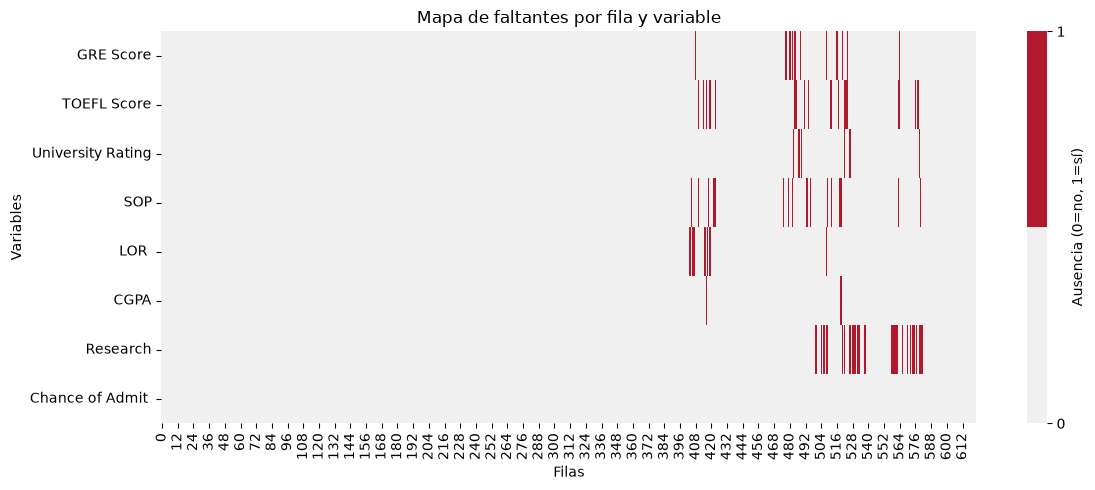

In [59]:
MISSINGNESS_PATTERN_COLUMN = "Patrón de faltantes"
NO_MISSINGNESS_LABEL = "Sin faltantes"
MISSINGNESS_FIGURE_SIZE = (12, 5)

missingness_matrix = admisiones_df[EXPLORATORY_ANALYSIS_COLUMNS].isna()
missingness_pattern_labels = missingness_matrix.apply(
    lambda row: " | ".join(row.index[row].tolist()) if row.any() else NO_MISSINGNESS_LABEL,
    axis=1,
)
missingness_patterns = (
    missingness_pattern_labels.value_counts()
    .rename_axis(MISSINGNESS_PATTERN_COLUMN)
    .reset_index(name="filas")
    .assign(porcentaje=lambda table: 100.0 * table["filas"] / len(admisiones_df))
)
display(missingness_patterns.style.format({"porcentaje": "{:.2f}"}))

plt.figure(figsize=MISSINGNESS_FIGURE_SIZE)
sns.heatmap(
    missingness_matrix.transpose(),
    cmap=["#f0f0f0", "#b2182b"],
    cbar_kws={"ticks": [0, 1], "label": "Ausencia (0=no, 1=sí)"},
)
plt.title("Mapa de faltantes por fila y variable")
plt.xlabel("Filas")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

## Baseline heurístico (no validado)

Esta referencia transparente no ajusta pesos ni estima rendimiento. Asigna mayor peso fijo a `CGPA`, pesos intermedios a `GRE Score` y `TOEFL Score`, y pesos menores a `University Rating` y `Research`, como síntesis comunicable del EDA. Los valores numéricos faltantes se reemplazan con medianas aprendidas solo del entrenamiento y `Research` faltante recibe el valor neutral fijo. Es un punto de comparación y comunicación, no evidencia de desempeño predictivo ni de influencia causal.

Protocolo futuro: separar primero los datos, construir la configuración solo con la partición de entrenamiento, predecir la validación y comparar el MAE con un baseline de media calculada en entrenamiento. No se calcula ninguna métrica en este notebook.

In [75]:
HEURISTIC_CGPA_WEIGHT = 0.40
HEURISTIC_GRE_WEIGHT = 0.22
HEURISTIC_TOEFL_WEIGHT = 0.18
HEURISTIC_UNIVERSITY_RATING_WEIGHT = 0.12
HEURISTIC_RESEARCH_WEIGHT = 0.08
HEURISTIC_NEUTRAL_RESEARCH_VALUE = 0.50
HEURISTIC_CGPA_RANGE = (6.0, 10.0)
HEURISTIC_GRE_RANGE = (260.0, 340.0)
HEURISTIC_TOEFL_RANGE = (80.0, 120.0)
HEURISTIC_UNIVERSITY_RATING_RANGE = (1.0, 5.0)
HEURISTIC_NUMERIC_RANGES = {
    "CGPA": HEURISTIC_CGPA_RANGE,
    "GRE Score": HEURISTIC_GRE_RANGE,
    "TOEFL Score": HEURISTIC_TOEFL_RANGE,
    "University Rating": HEURISTIC_UNIVERSITY_RATING_RANGE,
}
HEURISTIC_NUMERIC_WEIGHTS = {
    "CGPA": HEURISTIC_CGPA_WEIGHT,
    "GRE Score": HEURISTIC_GRE_WEIGHT,
    "TOEFL Score": HEURISTIC_TOEFL_WEIGHT,
    "University Rating": HEURISTIC_UNIVERSITY_RATING_WEIGHT,
}
HEURISTIC_RESEARCH_MAPPING = {True: 1.0, False: 0.0}


def build_heuristic_baseline(train_features, train_target):
    training_target = pd.Series(train_target).dropna().astype(float)
    if training_target.empty:
        raise ValueError("train_target debe contener al menos un valor observado.")

    numeric_medians = {
        column: pd.to_numeric(train_features[column], errors="coerce").median()
        for column in HEURISTIC_NUMERIC_RANGES
    }
    if any(pd.isna(median_value) for median_value in numeric_medians.values()):
        raise ValueError("Cada predictor numérico requiere un valor observado en entrenamiento.")

    return {
        "numeric_medians": numeric_medians,
        "target_minimum": training_target.min(),
        "target_maximum": training_target.max(),
        "neutral_research_value": HEURISTIC_NEUTRAL_RESEARCH_VALUE,
    }


def predict_heuristic_admission_probability(features, baseline_config):
    heuristic_score = pd.Series(0.0, index=features.index, dtype=float)

    for column, expected_range in HEURISTIC_NUMERIC_RANGES.items():
        expected_minimum, expected_maximum = expected_range
        imputed_values = pd.to_numeric(features[column], errors="coerce").fillna(
            baseline_config["numeric_medians"][column]
        )
        normalized_values = (
            imputed_values.clip(expected_minimum, expected_maximum) - expected_minimum
        ) / (expected_maximum - expected_minimum)
        heuristic_score += HEURISTIC_NUMERIC_WEIGHTS[column] * normalized_values

    research_values = (
        features[RESEARCH_COLUMN]
        .map(HEURISTIC_RESEARCH_MAPPING)
        .fillna(baseline_config["neutral_research_value"])
    )
    heuristic_score += HEURISTIC_RESEARCH_WEIGHT * research_values

    target_minimum = baseline_config["target_minimum"]
    target_maximum = baseline_config["target_maximum"]
    return (target_minimum + heuristic_score * (target_maximum - target_minimum)).clip(
        target_minimum, target_maximum
    )

## 📊 Análisis de resultados y conclusiones

### Evidencia observada

El conjunto tiene 623 filas y el objetivo no presenta valores faltantes. Los predictores sí: `Research` registra 29 ausencias, `TOEFL Score` 19, `SOP` 16, `GRE Score` 11, `LOR ` 8, `University Rating` 6 y `CGPA` 2. El patrón predominante es la completitud: 552 filas (88.60 %) no tienen faltantes en las variables exploradas; las ausencias restantes aparecen en combinaciones pequeñas y no permiten identificar por sí solas su mecanismo.

El EDA bivariable ya verificado muestra las asociaciones lineales más altas con el objetivo para `CGPA` (Pearson 0.883), `GRE Score` (0.821) y `TOEFL Score` (0.813). El cribado multivariable también confirma redundancia entre predictores: `GRE Score`-`CGPA` (0.843), `GRE Score`-`TOEFL Score` (0.838), `TOEFL Score`-`CGPA` (0.836), `SOP`-`LOR ` (0.735), `SOP`-`CGPA` (0.709) y `University Rating`-`CGPA` (0.706). Estas asociaciones describen covariación, no efectos causales ni aportes independientes.

### Implicaciones para el modelado

La imputación, la codificación de `Research` y cualquier selección o regularización de predictores deben ajustarse solo con cada partición de entrenamiento. La redundancia observada requiere evaluar la estabilidad de coeficientes y el beneficio incremental de las variables mediante validación, no eliminar predictores por correlación aislada. Las comparaciones condicionadas por `Research`, el VIF y los perfiles conjuntos de `CGPA` y `GRE Score` no tienen outputs almacenados; deben ejecutarse y, si informan decisiones, recalcularse dentro del flujo de entrenamiento antes de extraer conclusiones.

### Conclusión sobre la viabilidad de la heurística

La heurística es técnicamente viable como benchmark interpretable: sus entradas, pesos fijos y configuración dependiente del entrenamiento están definidos, y las medianas de imputación y el rango del objetivo se aprenden solo del entrenamiento. Aún no es empíricamente viable: una evaluación sin fuga de datos debe demostrar un error aceptable frente al baseline de media calculada en entrenamiento. No hay métricas ni resultados de desempeño almacenados en este notebook.

## 💡 Propuestas y siguientes ideas

1. Definir un pipeline reproducible que incorpore la imputación, la codificación de `Research` y el tratamiento de las escalas ordinales dentro de la validación cruzada.
2. Recalcular cuantiles, imputaciones y diagnósticos de colinealidad dentro de las particiones de entrenamiento y comparar alternativas de representación para las escalas ordinales.
3. Establecer una partición de prueba final y un protocolo de validación que compare la baseline heurística y la media de entrenamiento antes de emitir cualquier afirmación sobre desempeño.

## 📖 Referencias

- pandas. Documentación de `DataFrame.corr`, `dropna` e imputación: https://pandas.pydata.org/docs/
- seaborn. Documentación de `heatmap` y `scatterplot`: https://seaborn.pydata.org/
- scikit-learn. Guía sobre preprocesamiento y prevención de fuga de datos: https://scikit-learn.org/stable/common_pitfalls.html